# SHAP Interpretation of LASSO vs Ridge vs Elastic Net
## Hunt Dataset — GeoConvention 2018 Replication (Part 2)

**Prerequisites:** This notebook builds on the LASSO/Ridge/Elastic Net analysis in
[`speidel_hunt_lasso_replication.ipynb`](speidel_hunt_lasso_replication.ipynb).
Run that notebook first to understand the variable selection results.
Here we add SHAP interpretation to show why regularization should come *before*
feature importance analysis, not after.

## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import (LinearRegression, Lasso, Ridge, ElasticNet,
                                   LassoCV, ElasticNetCV)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score
import shap

hunt = pd.read_csv("../data/Table2_Hunt_2013_edit.csv")
hunt.columns = (hunt.columns.str.lower()
                             .str.replace(' ', '.', regex=False)
                             .str.replace('-', '.', regex=False))

# Create position.cat (same as Thomas: cut2(position, c(1, 2, 3)))
hunt['position.cat'] = pd.cut(hunt['position'], bins=[-np.inf, 1, 2, 3, np.inf],
                               labels=[0, 1, 2, 3]).astype(int)

# Design matrix (same as LASSO notebook)
position_dummies = pd.get_dummies(hunt['position.cat'], prefix='pos', drop_first=True, dtype=float)
predictor_cols = ['gross.pay', 'phi.h', 'pressure', 'random.1', 'random.2', 'gross.pay.transform']
X_df = pd.concat([hunt[predictor_cols], position_dummies], axis=1)
y = hunt['production'].values
feature_names = X_df.columns.tolist()

# Standardize — keep as DataFrame to preserve feature names in SHAP plots
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_df), columns=feature_names)

print(f"X shape: {X.shape}")
print(f"Features: {feature_names}")

X shape: (21, 8)
Features: ['gross.pay', 'phi.h', 'pressure', 'random.1', 'random.2', 'gross.pay.transform', 'pos_1', 'pos_2']


## 2. The Problem: SHAP on a Full OLS Model (Unstable)

When all predictors are included — including the correlated pair `gross.pay` and
`gross.pay.transform` — SHAP attributions are **unstable**. The two SHAP modes
(`"correlation_dependent"` vs `"interventional"`) give different feature rankings
because credit assignment is ambiguous between collinear features.

This is **not a bug in SHAP**. It is a fundamental property of the data: when two
variables carry the same information, any split of credit between them is arbitrary.

In [2]:
# Fit OLS with ALL predictors
lr_full = LinearRegression()
lr_full.fit(X, y)

# SHAP with correlation-aware assumption
explainer_corr = shap.LinearExplainer(lr_full, X, feature_perturbation="correlation_dependent")
shap_values_corr = explainer_corr.shap_values(X)

# SHAP with independence assumption
explainer_ind = shap.LinearExplainer(lr_full, X, feature_perturbation="interventional")
shap_values_ind = explainer_ind.shap_values(X)

print("OLS full model fitted. SHAP values computed under both assumptions.")
print(f"Correlation between gross.pay and gross.pay.transform: "
      f"{X['gross.pay'].corr(X['gross.pay.transform']):.3f}")

Estimating transforms: 100%|██████████| 1000/1000 [00:00<00:00, 4029.98it/s]

OLS full model fitted. SHAP values computed under both assumptions.
Correlation between gross.pay and gross.pay.transform: 0.972


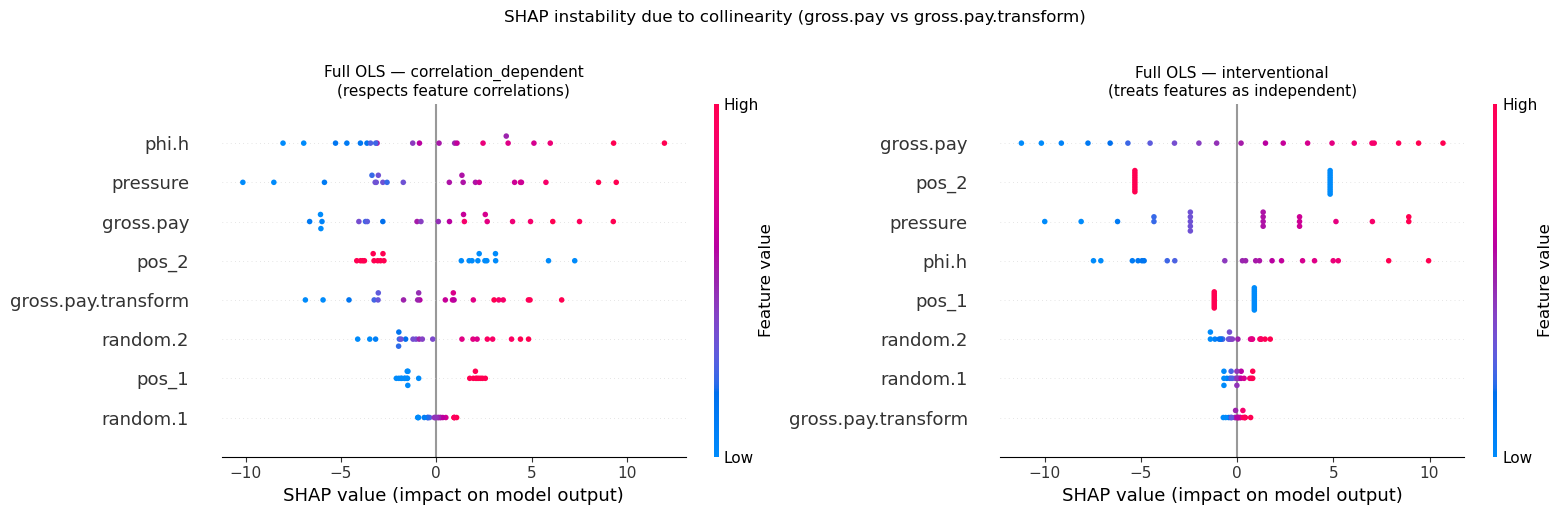

In [3]:
# Side-by-side comparison of the two SHAP modes on the full model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
shap.summary_plot(shap_values_corr, X, show=False, plot_size=None)
axes[0].set_title('Full OLS — correlation_dependent\n(respects feature correlations)', fontsize=11)

plt.sca(axes[1])
shap.summary_plot(shap_values_ind, X, show=False, plot_size=None)
axes[1].set_title('Full OLS — interventional\n(treats features as independent)', fontsize=11)

plt.suptitle('SHAP instability due to collinearity (gross.pay vs gross.pay.transform)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('shap_full_model_instability.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The two panels give different relative importance for `gross.pay` and
`gross.pay.transform`. Neither is "wrong" — the model cannot distinguish which one
matters when both carry essentially the same information. This is the collinearity problem
that variable selection is designed to solve.

## 3. The Fix: SHAP on the LASSO Model (Clean)

The 1SE LASSO already zeroed out `gross.pay.transform` (and other noise variables) in
`speidel_hunt_lasso_replication.ipynb`. When we apply SHAP to a model fitted only on
the surviving variables, the collinearity problem disappears — and both SHAP modes agree.

In [4]:
# Refit LASSO with 1SE rule (mirrors speidel_hunt_lasso_replication.ipynb)
loo = LeaveOneOut()
lasso_cv = LassoCV(cv=loo, random_state=123, n_alphas=100, max_iter=10000)
lasso_cv.fit(X, y)

mean_mse = np.mean(lasso_cv.mse_path_, axis=1)
std_mse  = np.std(lasso_cv.mse_path_,  axis=1) / np.sqrt(len(y))
idx_min  = np.argmin(mean_mse)
threshold = mean_mse[idx_min] + std_mse[idx_min]
candidates = np.where(mean_mse <= threshold)[0]
idx_1se   = candidates[0]
alpha_1se = lasso_cv.alphas_[idx_1se]

lasso_1se = Lasso(alpha=alpha_1se, max_iter=10000)
lasso_1se.fit(X, y)

surviving = [name for name, coef in zip(feature_names, lasso_1se.coef_) if coef != 0]
zeroed    = [name for name, coef in zip(feature_names, lasso_1se.coef_) if coef == 0]
print(f"alpha_1se = {alpha_1se:.4f}")
print(f"Surviving : {surviving}")
print(f"Zeroed out: {zeroed}")

alpha_1se = 0.9558
Surviving : ['gross.pay', 'phi.h', 'pressure', 'random.2', 'pos_2']
Zeroed out: ['random.1', 'gross.pay.transform', 'pos_1']


In [5]:
# Build reduced X with only surviving predictors and refit OLS
X_reduced = X[surviving]

lr_reduced = LinearRegression()
lr_reduced.fit(X_reduced, y)

explainer_corr_r = shap.LinearExplainer(lr_reduced, X_reduced,
                                         feature_perturbation="correlation_dependent")
shap_corr_r = explainer_corr_r.shap_values(X_reduced)

explainer_ind_r = shap.LinearExplainer(lr_reduced, X_reduced,
                                        feature_perturbation="interventional")
shap_ind_r = explainer_ind_r.shap_values(X_reduced)

print("Reduced model (LASSO survivors only) fitted. SHAP values computed.")

Estimating transforms: 100%|██████████| 1000/1000 [00:00<00:00, 6817.56it/s]

Reduced model (LASSO survivors only) fitted. SHAP values computed.


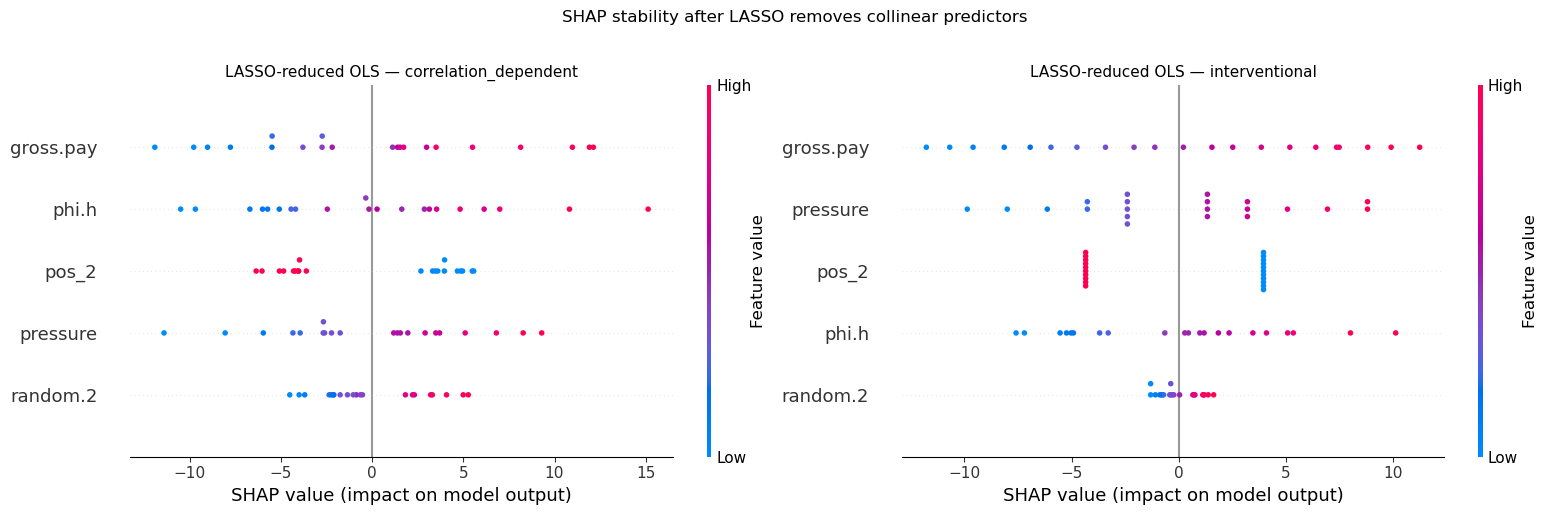

In [6]:
# Side-by-side comparison on the LASSO-reduced model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
shap.summary_plot(shap_corr_r, X_reduced, show=False, plot_size=None)
axes[0].set_title('LASSO-reduced OLS — correlation_dependent', fontsize=11)

plt.sca(axes[1])
shap.summary_plot(shap_ind_r, X_reduced, show=False, plot_size=None)
axes[1].set_title('LASSO-reduced OLS — interventional', fontsize=11)

plt.suptitle('SHAP stability after LASSO removes collinear predictors',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('shap_full_vs_lasso.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The two panels now give **consistent rankings**. With `gross.pay.transform`
removed by LASSO, the remaining predictors are no longer collinear,
and SHAP credit assignment is unambiguous.

## 4. SHAP on LASSO vs Ridge vs Elastic Net

Now we compare SHAP attributions across all three regularization methods. We use
`KernelExplainer` (model-agnostic) to treat all three models identically, passing
the full 21-sample dataset as background (fast enough at n=21).

In [7]:
# --- Ridge: manual LOO to find best alpha ---
ridge_alphas = np.logspace(-2, 4, 100)
ridge_mse = []
for a in ridge_alphas:
    scores = cross_val_score(Ridge(alpha=a), X, y, cv=loo,
                             scoring='neg_mean_squared_error')
    ridge_mse.append(-scores.mean())

best_ridge_alpha = ridge_alphas[np.argmin(ridge_mse)]
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X, y)
print(f"Best Ridge alpha: {best_ridge_alpha:.4f}")

# --- Elastic Net with 1SE rule ---
enet_cv = ElasticNetCV(l1_ratio=0.5, cv=loo, random_state=123, n_alphas=100, max_iter=10000)
enet_cv.fit(X, y)

enet_mean_mse = np.mean(enet_cv.mse_path_, axis=1)
enet_std_mse  = np.std(enet_cv.mse_path_,  axis=1) / np.sqrt(len(y))
enet_idx_min  = np.argmin(enet_mean_mse)
enet_threshold = enet_mean_mse[enet_idx_min] + enet_std_mse[enet_idx_min]
enet_candidates = np.where(enet_mean_mse <= enet_threshold)[0]
enet_alpha_1se = enet_cv.alphas_[enet_candidates[0]]

enet_1se = ElasticNet(alpha=enet_alpha_1se, l1_ratio=0.5, max_iter=10000)
enet_1se.fit(X, y)
print(f"Elastic Net alpha_1se: {enet_alpha_1se:.4f}")

enet_surviving = [n for n, c in zip(feature_names, enet_1se.coef_) if c != 0]
enet_zeroed    = [n for n, c in zip(feature_names, enet_1se.coef_) if c == 0]
print(f"E-Net surviving : {enet_surviving}")
print(f"E-Net zeroed out: {enet_zeroed}")

Best Ridge alpha: 0.8697
Elastic Net alpha_1se: 0.3582
E-Net surviving : ['gross.pay', 'phi.h', 'pressure', 'random.1', 'random.2', 'gross.pay.transform', 'pos_1', 'pos_2']
E-Net zeroed out: []


In [8]:
# KernelExplainer for all three models (background = full dataset, n=21 is fast)
background = X

print("Computing SHAP for LASSO...")
explainer_lasso = shap.KernelExplainer(lasso_1se.predict, background)
shap_lasso = explainer_lasso.shap_values(X)

print("Computing SHAP for Ridge...")
explainer_ridge = shap.KernelExplainer(ridge_best.predict, background)
shap_ridge = explainer_ridge.shap_values(X)

print("Computing SHAP for Elastic Net...")
explainer_enet = shap.KernelExplainer(enet_1se.predict, background)
shap_enet = explainer_enet.shap_values(X)

print("Done.")

Computing SHAP for LASSO...


100%|██████████| 21/21 [00:00<00:00, 153.88it/s]


Computing SHAP for Ridge...


100%|██████████| 21/21 [00:00<00:00, 163.22it/s]


Computing SHAP for Elastic Net...


100%|██████████| 21/21 [00:00<00:00, 180.17it/s]

Done.


## 5. Comparison Panel: LASSO vs Elastic Net vs Ridge

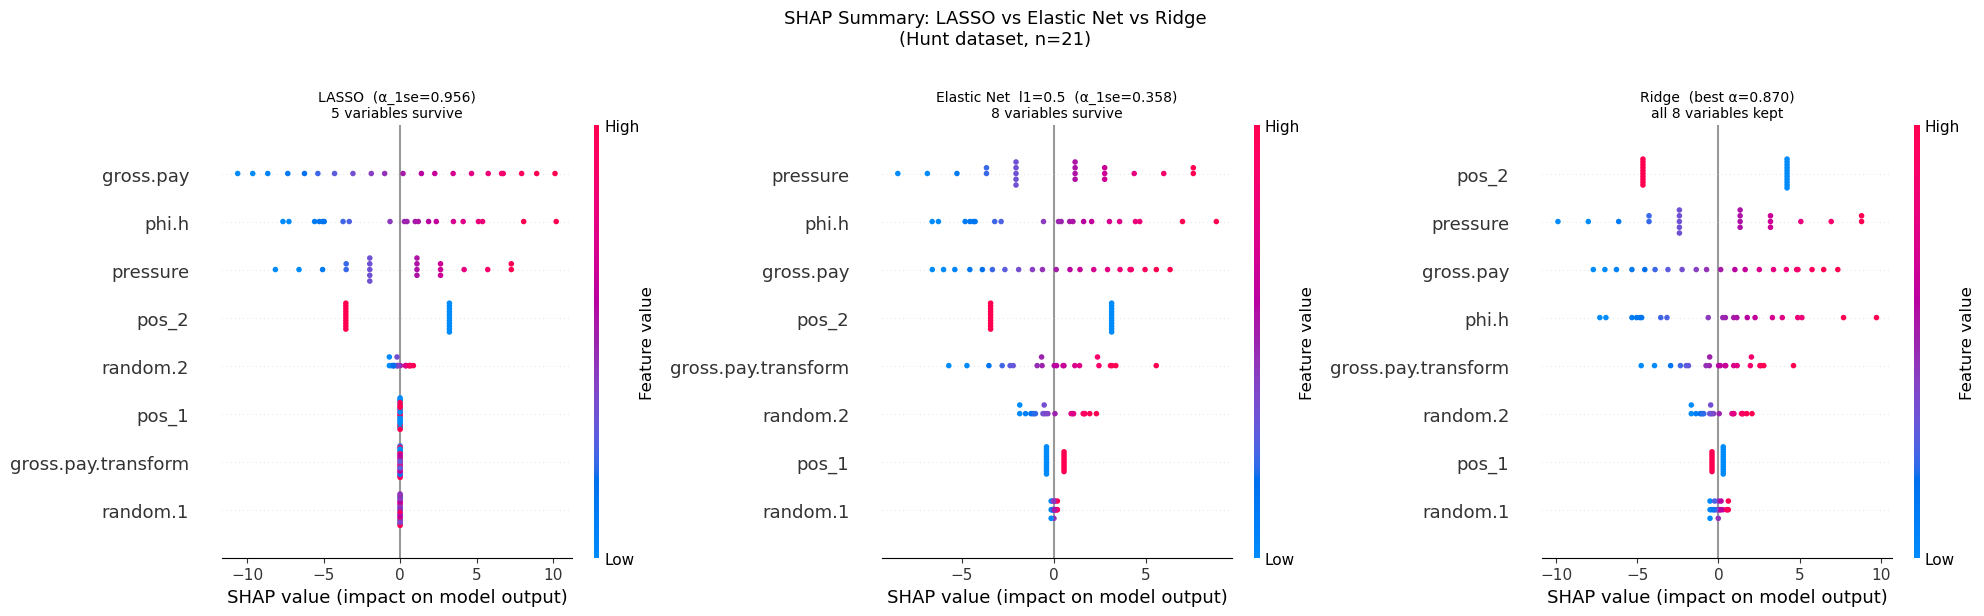

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plt.sca(axes[0])
shap.summary_plot(shap_lasso, X, show=False, plot_size=None)
axes[0].set_title(f'LASSO  (α_1se={alpha_1se:.3f})\n{len(surviving)} variables survive',
                  fontsize=10)

plt.sca(axes[1])
shap.summary_plot(shap_enet, X, show=False, plot_size=None)
axes[1].set_title(f'Elastic Net  l1=0.5  (α_1se={enet_alpha_1se:.3f})\n'
                  f'{len(enet_surviving)} variables survive', fontsize=10)

plt.sca(axes[2])
shap.summary_plot(shap_ridge, X, show=False, plot_size=None)
axes[2].set_title(f'Ridge  (best α={best_ridge_alpha:.3f})\nall 8 variables kept', fontsize=10)

plt.suptitle('SHAP Summary: LASSO vs Elastic Net vs Ridge\n(Hunt dataset, n=21)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('shap_comparison_panel.png', dpi=150, bbox_inches='tight')
plt.show()

## 5a. Why Elastic Net's SHAP is Messier than LASSO's

The Ridge component in Elastic Net (the L2 term, controlled by `l1_ratio`) tends to
**group** correlated predictors and shrink them together rather than eliminating one.
So `gross.pay` and `gross.pay.transform` may both survive with small non-zero
coefficients, and SHAP will split credit between them — less messily than pure Ridge,
but not as cleanly as pure LASSO.

The degree of contamination is directly proportional to `1 - l1_ratio`:
- `l1_ratio` closer to **1.0** (more LASSO-like) → SHAP cleans up
- `l1_ratio` closer to **0.0** (more Ridge-like) → SHAP gets messier

The relationship is not strictly linear, but the direction holds.

## 5b. The Fix: Two-Stage LASSO → Elastic Net

Run LASSO first to identify the surviving (non-collinear) variables, then refit
Elastic Net **only on those variables**. Now `gross.pay.transform` is gone before
Elastic Net ever sees the data, so its Ridge component can't spread credit onto it.
SHAP on this reduced model is as clean as the LASSO-reduced OLS in section 3.

In [10]:
# Two-stage fix: LASSO selection → Elastic Net on survivors only
X_reduced = X[surviving]  # 'surviving' from the LASSO 1SE fit above

enet_reduced = ElasticNet(alpha=enet_alpha_1se, l1_ratio=0.5)
enet_reduced.fit(X_reduced, y)

# SHAP on the reduced Elastic Net
explainer_enet_reduced = shap.KernelExplainer(enet_reduced.predict, X_reduced)
shap_enet_reduced = explainer_enet_reduced.shap_values(X_reduced)

100%|██████████| 21/21 [00:00<00:00, 604.95it/s]


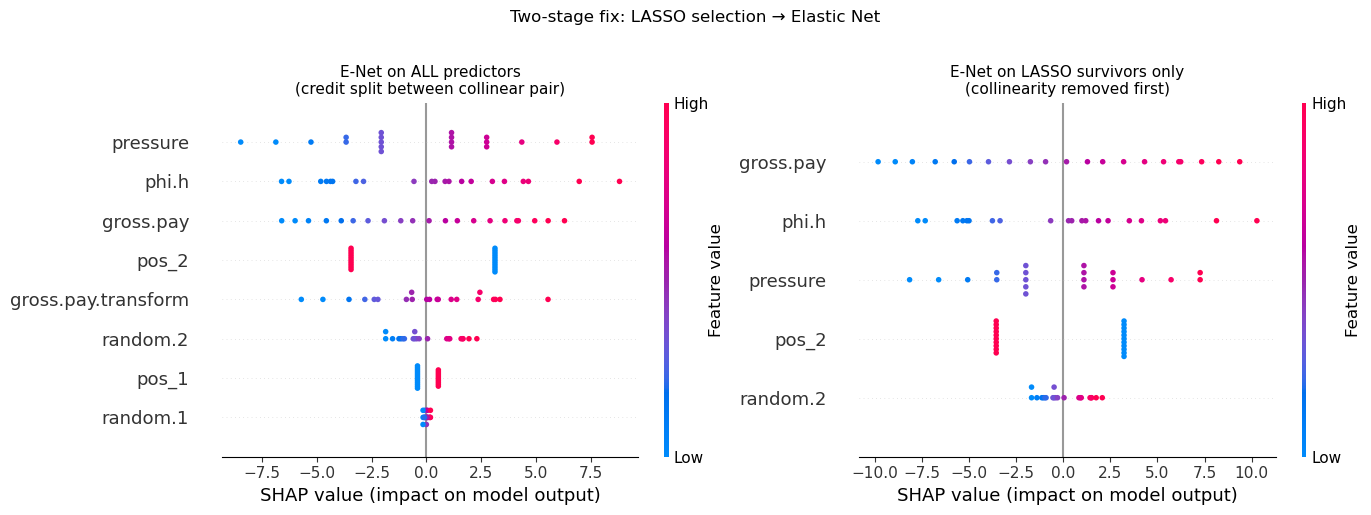

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.summary_plot(shap_enet, X, show=False, plot_size=None)
axes[0].set_title('E-Net on ALL predictors\n(credit split between collinear pair)', fontsize=11)

plt.sca(axes[1])
shap.summary_plot(shap_enet_reduced, X_reduced, show=False, plot_size=None)
axes[1].set_title('E-Net on LASSO survivors only\n(collinearity removed first)', fontsize=11)

plt.suptitle('Two-stage fix: LASSO selection → Elastic Net', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('shap_enet_full_vs_reduced.png', dpi=150, bbox_inches='tight')
plt.show()

**The key insight:** The Ridge component of Elastic Net creates SHAP instability
**only when the collinear variable is still present**. Once LASSO has removed it,
the Ridge component is harmless — it just smoothly shrinks the remaining
non-collinear coefficients.

**For completeness — Adaptive Elastic Net:** A more principled approach is the
Adaptive Elastic Net (Zou & Zhang, 2009), which weights each variable's penalty
by the inverse of a preliminary LASSO estimate. Variables that LASSO zeroed get
a disproportionately large penalty, making it nearly impossible for them to
re-enter. This is more rigorous but requires custom code in sklearn; for practical
purposes the two-stage approach above achieves the same result.

## 6. Key Takeaways

### Why regularization should come *before* SHAP, not after

1. **SHAP on a full model with correlated predictors gives unstable attributions.**
   The two SHAP modes (`correlation_dependent` vs `interventional`) disagree on the
   relative importance of `gross.pay` vs `gross.pay.transform` because the model
   cannot distinguish between them — they carry essentially the same information.

2. **LASSO resolves this by zeroing out redundant variables *before* interpretation.**
   Once `gross.pay.transform` (and other noise variables) are removed, both SHAP
   modes agree on feature rankings. The correct workflow is:
   **regularization first → then SHAP**.

3. **Ridge keeps all variables, so SHAP on Ridge retains the instability problem.**
   Ridge shrinks coefficients but never zeros them. SHAP spreads credit across `gross.pay`
   and `gross.pay.transform` in proportion to their (shrunk) Ridge coefficients, which
   is arbitrary for collinear features.

4. **Elastic Net is intermediate:** partial sparsity removes some collinearity but may
   not always zero the right pair. The degree of cleanup depends on `l1_ratio`.

5. **This explains the 2019 notebook (`variable_selection_07`) findings.**
   That notebook found different SHAP results across ExtraTrees, LinearRegression,
   and SVM — not because SHAP was broken, but because the *question* was ambiguous.
   The models disagreed on credit for collinear features, and SHAP faithfully reported
   that disagreement.

6. **SHAP describes the *model*, not the *world*.**
   If the model has ambiguous credit assignment due to collinearity, SHAP will report
   that ambiguity. Use regularization to make the problem well-posed, then use SHAP
   to explain the regularized model.

---
*Thomas Speidel's original R analysis (GeoConvention 2018) used `glmnet`'s Fortran
implementation. This Python replication uses sklearn's coordinate descent. Results
are qualitatively equivalent but numerically different due to implementation
differences in path computation, standardization handling, and alpha grid construction.*